#Name: Aliza Lama
#Student ID: 2408583

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
!pip install pillow matplotlib numpy

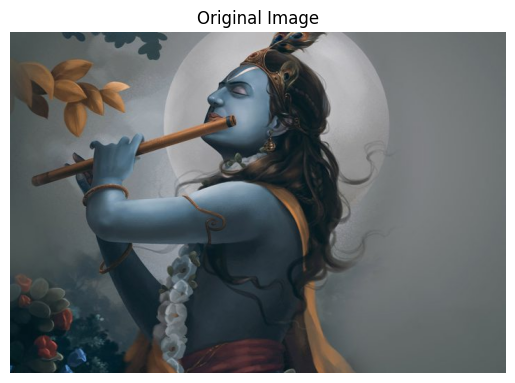

In [ ]:
# Load image
image = Image.open("/content/drive/MyDrive/AI&ML/data/Krishna-wallpaper-for-Home-710x488.jpg")  # Replace with your image filename
image_array = np.array(image)

# Display using matplotlib
plt.imshow(image_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

#2. Display Top-Left 100x100 Pixels

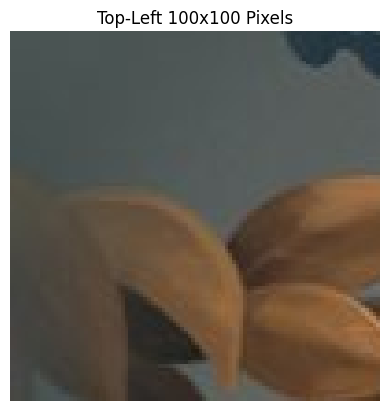

In [ ]:
# Extracing top-left 100x100 region
top_left = image_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top-Left 100x100 Pixels")
plt.axis("off")
plt.show()

#3. Show R, G, B Channels

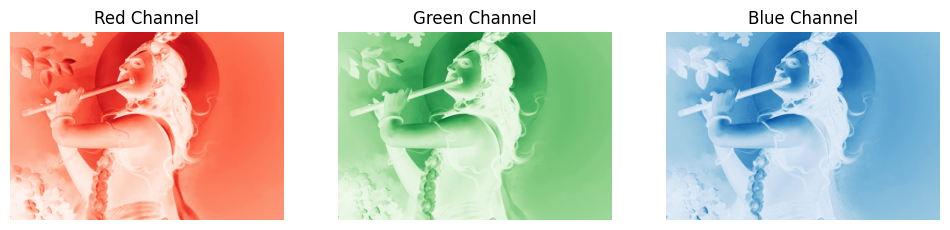

In [ ]:
# Separate channels
R = image_array[:, :, 0]
G = image_array[:, :, 1]
B = image_array[:, :, 2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

#4. Modify Top 100x100 Pixels to 210

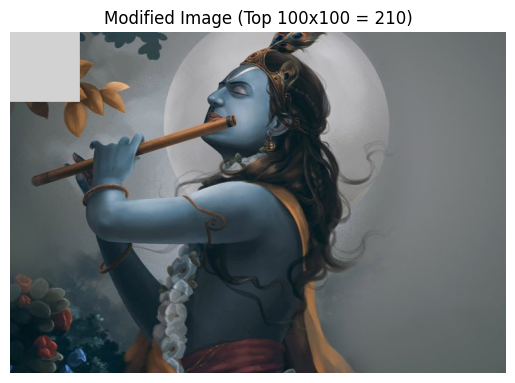

In [ ]:
# Copy image to avoid modifying original
modified_image = image_array.copy()

# Set top-left 100x100 region to 210 (light gray)
modified_image[0:100, 0:100] = 210

plt.imshow(modified_image)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

#EXERCISE 2

#1.Load and Display Grayscale Image

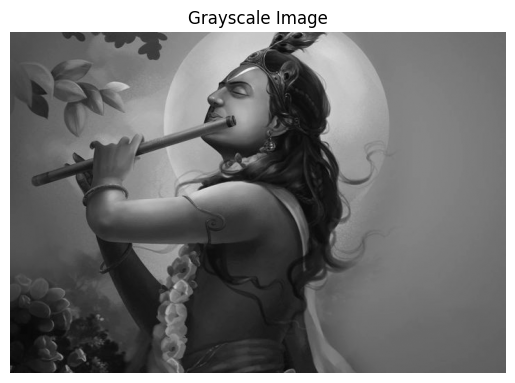

In [ ]:
# Load grayscale image
gray_image = Image.open("/content/drive/MyDrive/AI&ML/data/Krishna-wallpaper-for-Home-710x488.jpg").convert("L")
gray_array = np.array(gray_image)

plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

#2. Extract Middle 150 Pixel Section

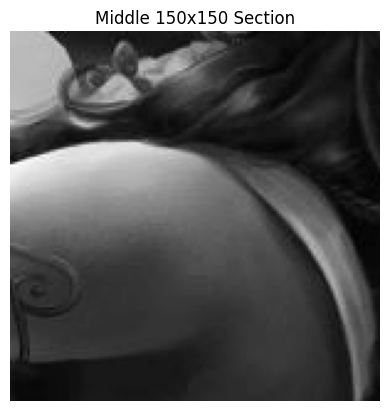

In [ ]:
h, w = gray_array.shape

center_h = h // 2
center_w = w // 2

middle_section = gray_array[
    center_h - 75:center_h + 75,
    center_w - 75:center_w + 75
]

plt.imshow(middle_section, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

#3. Apply Threshold

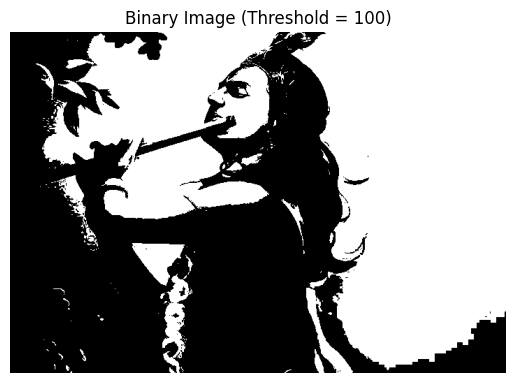

In [ ]:
binary_image = gray_array.copy()

binary_image[binary_image < 100] = 0
binary_image[binary_image >= 100] = 255

plt.imshow(binary_image, cmap="gray")
plt.title("Binary Image (Threshold = 100)")
plt.axis("off")
plt.show()

#4. Rotate 90 Degrees Clockwise

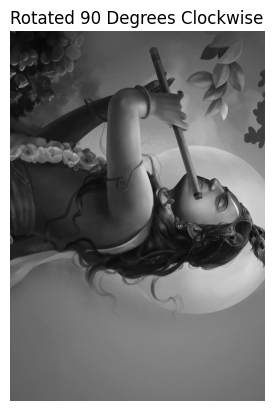

In [ ]:
#Using NumPy
rotated_image = np.rot90(gray_array, k=-1)

plt.imshow(rotated_image, cmap="gray")
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

#5. Convert Grayscale to RGB

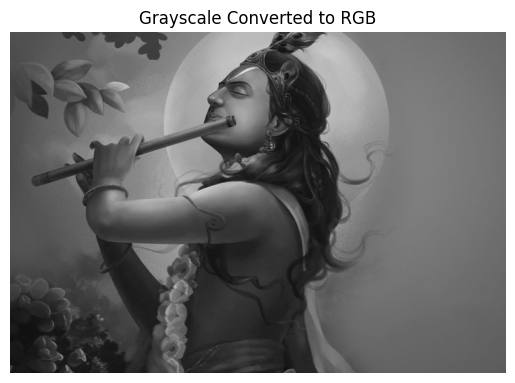

In [ ]:
rgb_image = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

#EXERCISE 3
#PCA from Scratch for Image Compression

#Step 1: Load and Prepare Data

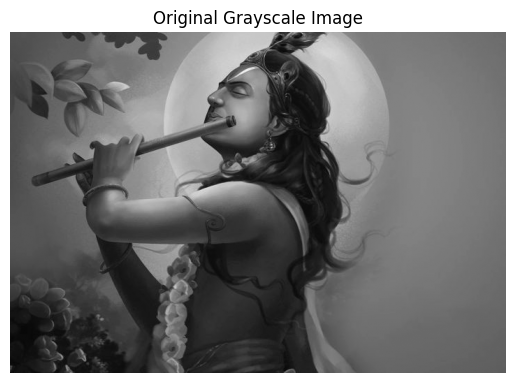

In [ ]:
# Convert image to grayscale
image = Image.open("/content/drive/MyDrive/AI&ML/data/Krishna-wallpaper-for-Home-710x488.jpg").convert("L")
img = np.array(image, dtype=float)

plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

In [ ]:
#Center the data:
# Mean centering
mean = np.mean(img, axis=0)
centered_data = img - mean

In [ ]:
#Covariance matrix:
cov_matrix = np.cov(centered_data, rowvar=False)

In [ ]:
#Step 2: Eigen Decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues descending
sorted_index = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

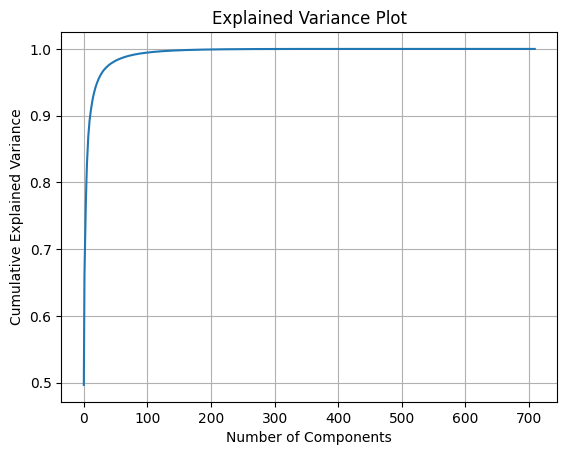

In [ ]:
#Explained variance:
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid()
plt.show()

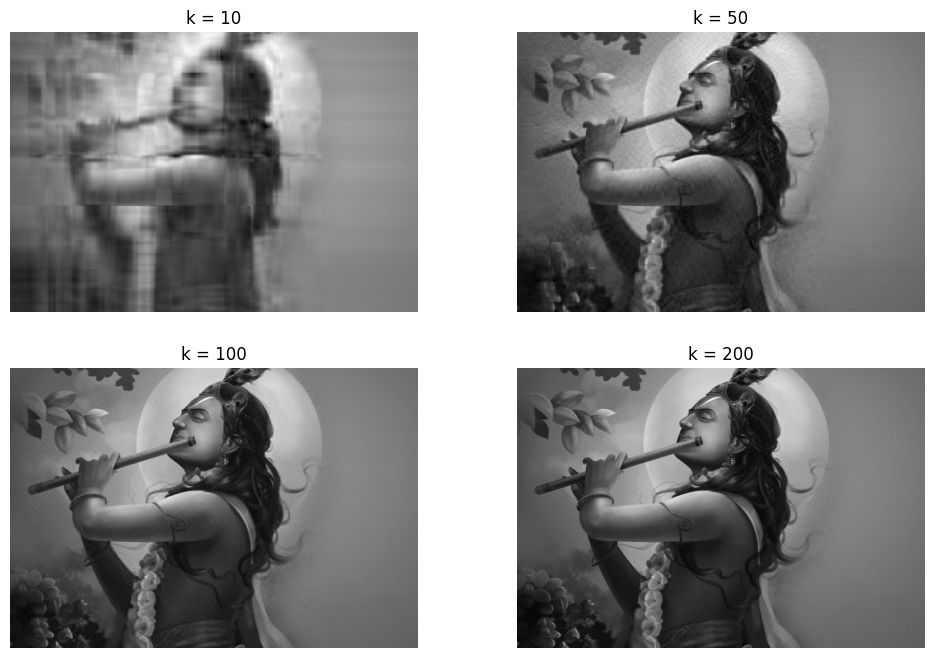

In [ ]:
#Step 3: Reconstruction
#Choose different k values:
k_values = [10, 50, 100, 200]

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):
    pcs = eigenvectors[:, :k]
    projection = np.dot(centered_data, pcs)
    reconstruction = np.dot(projection, pcs.T) + mean

    plt.subplot(2,2,i+1)
    plt.imshow(reconstruction, cmap="gray")
    plt.title(f"k = {k}")
    plt.axis("off")

plt.show()